# Visits to American National Parks: Exploratory Data Analysis

**SI 699 mini project**

This notebook explores the National Park Service's by-month visitor-use dataset
(1979–2023, 63 parks) to find a defensible, non-obvious claim about *how*
people visit national parks, and to back that claim with statistics rather than
a single chart.

**Data source:** NPS Visitor Use Statistics, by-month extract, distributed via
[Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)
(Walsh et al.). See the accompanying [data essay](https://www.responsible-datasets-in-context.com/posts/np-data/?tab=data-essay)
for collection methodology and known caveats, cited throughout this notebook.

## Contents
1. [Data and methodology](#Data-and-methodology)
2. [Finding 1: visitation is de-seasonalizing](#Finding-1)
3. [Finding 2: overnight camping is declining relative to visits](#Finding-2)
4. [Supporting context: seasonality by park and the 2020 shock](#Supporting-context)
5. [Limitations and generalizability](#Limitations)

The write-up that these findings feed into lives in a separate notebook,
[`mini_project_draft.ipynb`](mini_project_draft.ipynb): claim, analysis, elaboration, discussion, and
topics for further exploration.


## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import npdata
import npviz

npviz.apply_style()
pd.set_option("display.max_columns", 50)

import matplotlib, statsmodels, scipy
print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__} | "
      f"statsmodels {statsmodels.__version__} | scipy {scipy.__version__}")


pandas 3.0.5 | numpy 2.5.3 | matplotlib 3.11.2 | statsmodels 0.15.0 | scipy 1.18.1


*Reusable plotting and analysis code lives in [`src/npviz.py`](../src/npviz.py)
and [`src/npdata.py`](../src/npdata.py) rather than inline in this notebook, so the
same styling and statistical helpers are used consistently across every figure
(see `requirements.txt` for exact package versions to reproduce this analysis).*

## Data and methodology <a id='Data-and-methodology'></a>

In [2]:
df = npdata.load_by_month()
print(f"{df.shape[0]:,} rows · {df.ParkName.nunique()} parks · {df.Year.min()}–{df.Year.max()}")
df.head(3)


33,395 rows · 63 parks · 1979–2023


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry,Date,ZeroMonth,ZeroYear
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0,1979-01-01,False,False
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0,1979-02-01,False,False
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0,1979-03-01,False,False


**Data dictionary:**

In [3]:
npdata.data_dictionary()

,Meaning
Field,
ParkName,Park name as published by NPS (63 parks design...
UnitCode,Four-letter NPS unit code (stable key)
ParkType,Constant: 'National Park'
Region,NPS administrative region (6 values)
State,Primary state (30 values); multi-state parks l...
Year / Month,Calendar year (1979-2023) and month (1-12)
RecreationVisits,Counted recreation visits (the headline visita...
NonRecreationVisits,"Commuter, through-traffic, staff, research visits"
TentCampers / RVCampers,"Overnight stays in front-country campgrounds, ..."


**Cleaning applied** (see `npdata.load_by_month`): stripped a UTF-8 BOM and
trailing whitespace from text fields, so `"Northeast "` becomes `"Northeast"`;
added a month-start `Date` column; flagged individual zero-visit months
(`ZeroMonth`) and any park-year containing one (`ZeroYear`) rather than
dropping them, since the data essay documents that some zeros reflect
non-reporting rather than a true absence of visitors (e.g. Kobuk Valley NP,
2014–2015). No rows were removed.

**Coverage check.** Is the panel complete enough to trend on?


In [4]:
coverage = df.groupby("ParkName")["Date"].agg(n_months="count", first="min", last="max")
coverage["expected"] = ((coverage["last"].dt.year - coverage["first"].dt.year) * 12
                         + (coverage["last"].dt.month - coverage["first"].dt.month) + 1)
coverage["missing_months"] = coverage["expected"] - coverage["n_months"]
print(f"Parks with any missing month: {(coverage.missing_months > 0).sum()} / {len(coverage)}")
coverage.sort_values("missing_months", ascending=False).head(5)


Parks with any missing month: 3 / 63


,n_months,first,last,expected,missing_months
ParkName,,,,,
National Park of American Samoa,240,2002-01-01,2023-12-01,264,24
Katmai NP & PRES,528,1979-01-01,2023-12-01,540,12
Channel Islands NP,539,1979-01-01,2023-12-01,540,1
Acadia NP,540,1979-01-01,2023-12-01,540,0
Petrified Forest NP,540,1979-01-01,2023-12-01,540,0


In [5]:
zero_park_years = df[df.ZeroMonth].groupby("ParkName")["Year"].nunique().sort_values(ascending=False)
print(f"{len(zero_park_years)} parks have >=1 zero-visit month; "
      f"{df.ZeroYear.sum() / len(df):.1%} of rows fall in a park-year containing one.")
zero_park_years.head(6)


35 parks have >=1 zero-visit month; 3.9% of rows fall in a park-year containing one.


ParkName
Gates of the Arctic NP & PRES    21
Katmai NP & PRES                 18
Isle Royale NP                   11
North Cascades NP                11
Lake Clark NP & PRES              6
Kenai Fjords NP                   5
Name: Year, dtype: int64

The panel has no gaps *inside* any park's own reporting window (one park is
one month short out of 33,395 rows). But the coverage table above measures
each park from its own first to last year, so it does not flag parks that
enter the file late. Eight do: the five large Alaska parks and preserves
begin in 1982, New River Gorge in 1984, Congaree in 1985 and the National
Park of American Samoa in 2002. Together they account for 1.8% of all
recorded visits. The [balanced-panel check](mini_project_draft.ipynb) in the draft notebook
refits the headline trend using only the 55 parks observed across the whole
1979–2023 window, and the result is unchanged.

Zero-visit months are concentrated in a handful of remote Alaska and Pacific
parks with known reporting gaps, which is consistent with the data essay's
caveats. Both findings below are checked with and without those park-years
(**Robustness** cells) and the conclusions do not change, so we keep the
full panel rather than dropping data that may simply be under-reported
rather than truly zero.


## Finding 1: visitation is de-seasonalizing <a id='Finding-1'></a>

**Metric.** For each year, the share of that year's national recreation
visits falling in June to August, the traditional peak season. We fit an
ordinary-least-squares trend of this share on year, using Newey-West (HAC)
standard errors to allow for serial correlation across adjacent years
(see `npdata.trend`).


In [6]:
national_matrix = npdata.monthly_matrix(df, ["Year"])
summer = npdata.summer_share(national_matrix)
fit = npdata.trend(summer)
print(f"Slope: {fit.slope:+.3f} share-points per decade "
      f"(95% CI {fit.ci_low:+.3f} to {fit.ci_high:+.3f}), p = {fit.p_value:.2e}, n = {int(fit.n)} years")


Slope: -0.016 share-points per decade (95% CI -0.020 to -0.012), p = 1.50e-15, n = 45 years


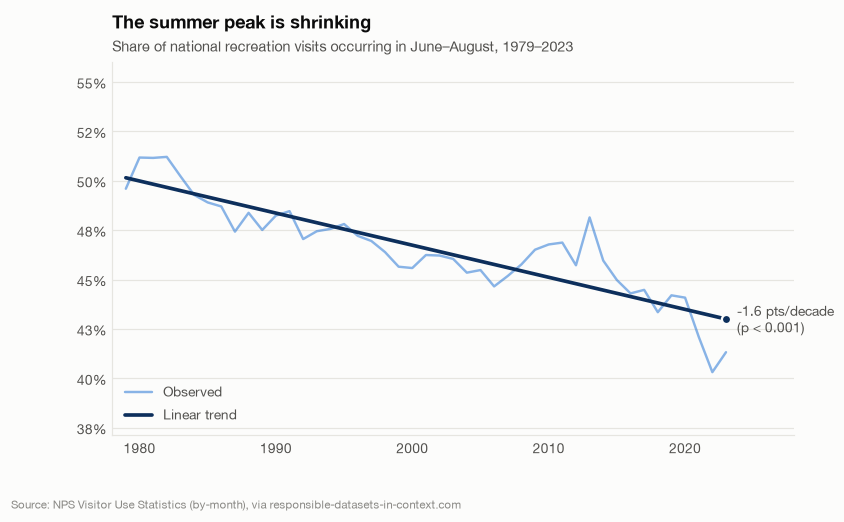

In [7]:
fig, ax = npviz.new_figure(8, 4.4)
years = summer.index.to_numpy(dtype=float)
pred = fit.slope / 10 * (years - years.mean()) + summer.mean()
ax.fill_between(years, pred - 0.05, pred + 0.05, alpha=0)  # keep autoscale consistent
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.55, label="Observed")
ax.plot(years, pred, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
npviz.end_label(ax, years[-1], pred[-1], f"{fit.slope*100:+.1f} pts/decade\n(p < 0.001)",
                 color=npviz.DARK_BLUE, dx=0.8)
ax.set_xlim(1978, 2028)
npviz.title(ax, "The summer peak is shrinking",
            "Share of national recreation visits occurring in June–August, 1979–2023")
ax.legend(loc="lower left")
npviz.source_note(fig)
npviz.save(fig, "01_summer_share_trend")
plt.show()


### Robustness checks

In [8]:
checks = {}
checks["Main (visit-weighted national share)"] = fit

# (a) unweighted across parks -- is this a few huge parks, or broad-based?
park_year_matrix = npdata.monthly_matrix(df, ["ParkName", "Year"])
park_share = npdata.summer_share(park_year_matrix).dropna()
unweighted = park_share.groupby(level="Year").mean()
checks["Unweighted mean across the 63 parks"] = npdata.trend(unweighted)

# (b) excluding the COVID-disrupted years
checks["Excluding 2020-2021"] = npdata.trend(summer.drop(index=[2020, 2021]))

# (c) park-specific peak season instead of a fixed calendar summer
checks["Park-specific best 3 consecutive months"] = npdata.trend(npdata.peak3_share(national_matrix))

pd.DataFrame(checks).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(4)


,slope,ci_low,ci_high,p_value,n
Main (visit-weighted national share),-0.0163,-0.0202,-0.0123,0.0,45.0
Unweighted mean across the 63 parks,-0.0096,-0.0134,-0.0058,0.0,45.0
Excluding 2020-2021,-0.0160,-0.0204,-0.0117,0.0,43.0
Park-specific best 3 consecutive months,-0.0159,-0.0199,-0.0118,0.0,45.0


The trend survives every robustness check. It is not an artifact of how
"summer" is defined, it is not driven by 2020's closures, and it is not an
aggregation effect from a few large parks, since the average individual park
shows the same decline. To see whether it is universal or concentrated, we
fit the same trend separately for each of the 63 parks, requiring at least 20
years of data:


In [9]:
per_park = npdata.park_trends(park_share)
print(f"{len(per_park)} parks with sufficient history · "
      f"{(per_park.slope < 0).sum()} trending down, {(per_park.slope > 0).sum()} trending up · "
      f"{per_park.significant.sum()} individually significant at p<.05 "
      f"({(per_park.slope < 0).loc[per_park.significant].sum()} of those are declines)")


62 parks with sufficient history · 43 trending down, 19 trending up · 43 individually significant at p<.05 (34 of those are declines)


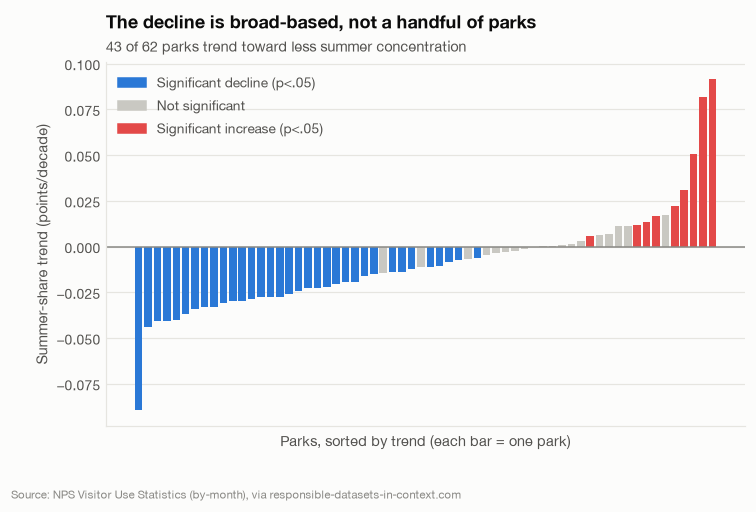

In [10]:
from matplotlib.patches import Patch

fig, ax = npviz.new_figure(7.5, 4.3)
colors = [npviz.RED if s and sl > 0 else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
          for s, sl in zip(per_park.significant, per_park.slope)]
ax.bar(range(len(per_park)), per_park.slope, color=colors, width=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xticks([])
ax.set_xlabel("Parks, sorted by trend (each bar = one park)")
ax.set_ylabel("Summer-share trend (points/decade)")
npviz.title(ax, "The decline is broad-based, not a handful of parks",
            f"{(per_park.slope < 0).sum()} of {len(per_park)} parks trend toward less summer concentration")
legend_handles = [
    Patch(color=npviz.BLUE, label="Significant decline (p<.05)"),
    Patch(color=npviz.EMPHASIS_GRAY, label="Not significant"),
    Patch(color=npviz.RED, label="Significant increase (p<.05)"),
]
ax.legend(handles=legend_handles, loc="upper left", ncol=1)
npviz.source_note(fig)
npviz.save(fig, "02_park_trend_distribution")
plt.show()


**Interpretation.** Most parks (43 of 62 with adequate history) are trending
toward *less* summer concentration, and this is the dominant, statistically
significant pattern. A minority trend the other way and become *more*
summer-concentrated. These are mostly a handful of Alaska parks (Katmai,
Wrangell–St. Elias, Lake Clark) with short seasons and growing tourism. Both
patterns are real and worth reporting: the national average hides some
variation, but the median park is de-seasonalizing.


## Finding 2: overnight camping is declining relative to visits <a id='Finding-2'></a>

**Metric.** Overnight stays (tent campers, RV campers, backcountry campers)
per 1,000 recreation visits, by year. We fit the same OLS-with-HAC trend on
the *log* of each rate, so the slope reads as a percent change per decade.
That suits a rate which can only be positive and which changes
multiplicatively rather than linearly.


In [11]:
annual = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
per_1000 = annual[["TentCampers", "RVCampers", "Backcountry"]].div(annual["RecreationVisits"], axis=0) * 1000

camp_fits = {c: npdata.trend(per_1000[c], log=True) for c in per_1000.columns}
pd.DataFrame(camp_fits).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(2).rename(
    columns={"slope": "% change / decade", "ci_low": "CI low", "ci_high": "CI high"})


,% change / decade,CI low,CI high,p_value,n
TentCampers,-14.33,-17.12,-11.45,0.00,45.0
RVCampers,-23.95,-26.48,-21.34,0.00,45.0
Backcountry,-1.64,-5.14,1.98,0.37,45.0


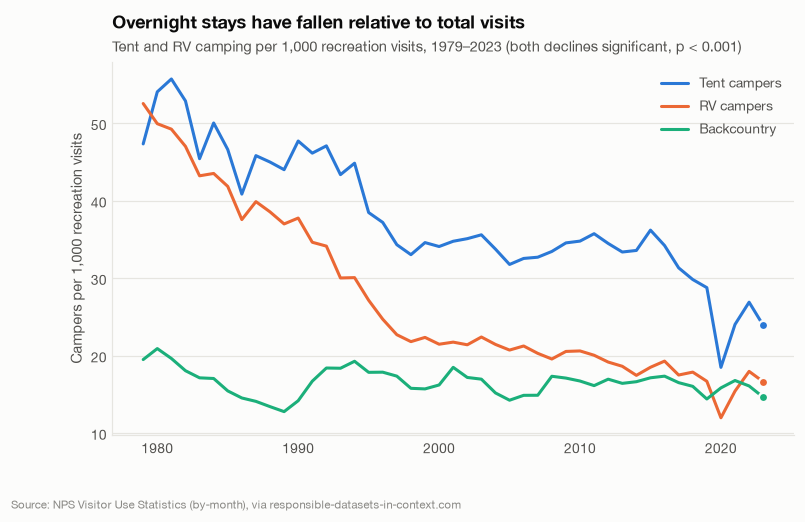

In [12]:
fig, ax = npviz.new_figure(8, 4.4)
series_colors = {"TentCampers": npviz.BLUE, "RVCampers": npviz.ORANGE, "Backcountry": npviz.AQUA}
labels = {"TentCampers": "Tent campers", "RVCampers": "RV campers", "Backcountry": "Backcountry"}
for col, color in series_colors.items():
    ax.plot(per_1000.index, per_1000[col], color=color, lw=2, label=labels[col])
    npviz.end_label(ax, per_1000.index[-1], per_1000[col].iloc[-1], "", color=color, dx=0)
ax.set_ylabel("Campers per 1,000 recreation visits")
npviz.title(ax, "Overnight stays have fallen relative to total visits",
            "Tent and RV camping per 1,000 recreation visits, 1979–2023 (both declines significant, p < 0.001)")
ax.legend(loc="upper right")
npviz.source_note(fig)
npviz.save(fig, "03_overnight_rate_trend")
plt.show()


Tent camping per 1,000 visits has fallen roughly 14% per decade and RV
camping roughly 24% per decade, both at *p* < 0.001. Backcountry camping
shows no significant trend. The three also diverge in raw counts. Between
1979–1983 and 2019–2023 tent stays fell 25% and RV stays fell 49%, while
backcountry stays *grew* 26%. Front-country camping has therefore declined
outright, not merely failed to keep pace with a growing visitor base; the
[draft notebook](mini_project_draft.ipynb) separates those two possibilities
directly.

### Is this a mix-shift, or a real behavior change?

Total visits have grown fastest in parks that were never camping-heavy, such
as urban-adjacent or drive-through parks. A shift-share decomposition
separates how much of the change in the *national* camping rate comes from
(a) individual parks camping less ("within") and how much comes from (b)
visit growth shifting toward parks that camp less ("between", or mix). It
compares 1979–1983 with 2017–2023. The 2020–2021 years sit far enough from
both endpoints not to be decisive, but see the note below.


In [13]:
decomp = npdata.shift_share(df, early=(1979, 1983), late=(2017, 2023),
                            numerator=["TentCampers", "RVCampers"])
decomp.round(3)


rate_early           0.099
rate_late            0.044
total_change        -0.056
within_share         0.995
between_share       -0.233
interaction_share    0.238
within_sym           1.114
between_sym         -0.114
dtype: float64

The decomposition covers front-country camping, tent plus RV, since
backcountry shows no trend to decompose. **111.4%** of the drop is
attributable to **within-park** change under a symmetric split of the
interaction term (`within_sym` above). The same set of parks that were
high-camping in 1979 are, on average, still high-camping in relative terms,
but camping rates have fallen inside almost every park. Visit growth shifting
toward lower-camping parks (`between_sym`) actually *offsets* the decline
slightly, by −11.4%.

The raw, unsymmetrized split leaves a sizeable interaction term of 23.8%,
which is why we report the symmetric version. Splitting that cross-term
evenly avoids assigning a large and hard-to-interpret residual to either
side. Either way, this rules out the alternative explanation that national
growth simply happened to concentrate in already-low-camping parks.

We can see the same within-park pattern directly by tracking a few of the
largest, longest-running parks on their own. Each panel is annotated with
that park's own trend estimate, since not every park shows the decline
equally:


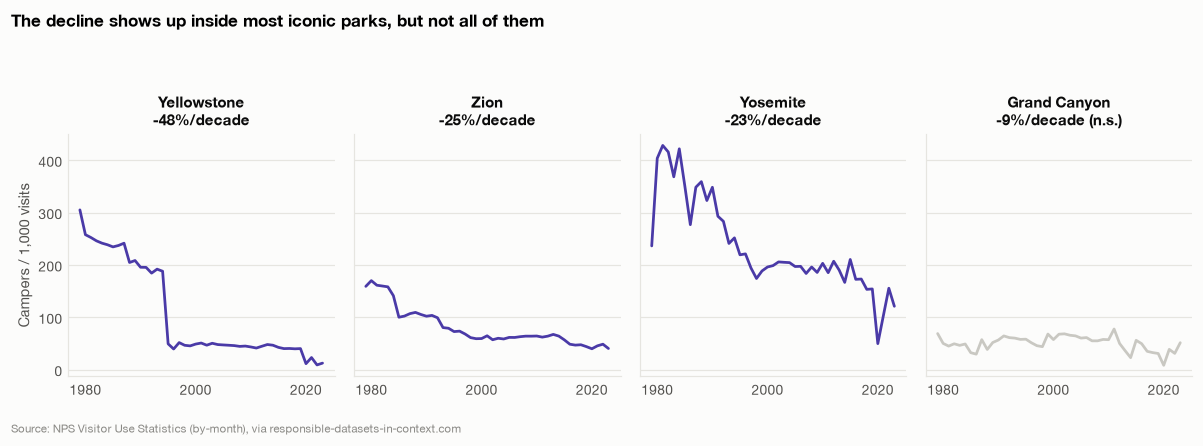

In [14]:
big_parks = ["Yellowstone NP", "Zion NP", "Yosemite NP", "Grand Canyon NP"]
fig, axes = plt.subplots(1, len(big_parks), figsize=(11, 3.4), sharey=True)
for ax, park in zip(axes, big_parks):
    sub = df[df.ParkName == park].groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers"]].sum()
    rate = (sub["TentCampers"] + sub["RVCampers"]) / sub["RecreationVisits"] * 1000
    park_fit = npdata.trend(rate, log=True)
    color = npviz.VIOLET if park_fit.p_value < 0.05 else npviz.EMPHASIS_GRAY
    ax.plot(rate.index, rate.values, color=color, lw=1.8)
    star = "" if park_fit.p_value < 0.05 else " (n.s.)"
    ax.set_title(f"{park.replace(' NP', '')}\n{park_fit.slope:+.0f}%/decade{star}",
                 fontsize=9.5, color=npviz.TEXT_PRIMARY, loc="center")
    ax.set_xticks([1980, 2000, 2020])
    ax.grid(axis="y", color=npviz.GRID, lw=0.8)
axes[0].set_ylabel("Campers / 1,000 visits")
fig.suptitle("The decline shows up inside most iconic parks, but not all of them",
             fontsize=11, fontweight="bold", x=0.01, ha="left", y=1.08)
npviz.source_note(fig)
npviz.save(fig, "04_within_park_camping")
plt.tight_layout()
plt.show()


## Supporting context <a id='Supporting-context'></a>

Two further patterns give context for the findings above. Neither is a
standalone claim. The first is how seasonal each park is, which explains why
the national trend is not universal. The second is the 2020 shock, which we
treat as texture and as a data-quality note rather than as a generalisable
trend.

### How seasonal is each park, and when does it peak?

**Why we measure this.** An earlier draft sorted parks by their busiest
month, then labelled two groups by hand using cutoffs at April and August.
Feedback on that draft asked for a quantitative measure of what "more or
less seasonal" and "seasonal type" actually mean. That was a fair point. The
labels described the picture rather than measuring it, the cutoffs were
arbitrary, and nothing in them captured how *strong* a park's season was. A
park with 84% of its visits in three months and a park with 25% spread
evenly could both be filed under "summer peak".

So we now measure two things separately, because they are two different
questions (`npdata.seasonality_indices`):

1. **How seasonal**, measured two ways that are not interchangeable.
   `concentration` is the resultant length of the twelve monthly shares
   placed on a circle: 1 means every visit lands in one month, and 0 means no
   single time of year dominates. Note that 0 covers two different calendars,
   an even spread *and* a park with offsetting peaks six months apart, which
   would cancel. `eff_months` is the exponential of the Shannon entropy of
   the same shares, read as an effective number of equally busy months, with
   12 meaning flat. It ignores the order of the months, so it does catch the
   bimodal case that `concentration` misses. Across these 63 parks the two
   agree closely (*r* = −0.98), so nothing below turns on the difference, but
   they are not the same measure.
2. **When it peaks**, as the direction of the resultant vector. This is a
   circular mean on a 1 to 12 scale where month *m*'s midpoint is exactly
   *m*, so 7.0 is mid-July. Unlike taking the busiest month, it does not jump
   between neighbouring months when their counts are nearly tied, and it
   wraps correctly for a park that peaks around New Year. It only means
   something when `concentration` is well clear of 0; for a near-flat
   calendar the direction is noise, which is what the floor below is for.

Monthly counts are converted to visits per day first, otherwise February
scores as quiet only because it is short.

In [15]:
recent = df[df.Year.between(2019, 2023)]
season_recent = npdata.seasonality_indices(npdata.monthly_matrix(recent, ["ParkName"])).dropna()

extremes = pd.concat([season_recent.nsmallest(5, "concentration"),
                      season_recent.nlargest(5, "concentration").iloc[::-1]])
extremes.index = ([f"least seasonal: {p}" for p in season_recent.nsmallest(5, "concentration").index]
                  + [f"most seasonal: {p}" for p in season_recent.nlargest(5, "concentration").index[::-1]])
extremes[["concentration", "eff_months", "peak_month"]].round(2)


,concentration,eff_months,peak_month
least seasonal: Haleakala NP,0.02,11.96,3.11
least seasonal: Congaree NP,0.04,11.78,3.78
least seasonal: Hawaii Volcanoes NP,0.04,11.88,11.74
least seasonal: Dry Tortugas NP,0.05,11.94,4.04
least seasonal: White Sands NP,0.07,11.73,4.76
most seasonal: Kenai Fjords NP,0.83,4.74,7.14
most seasonal: Lake Clark NP & PRES,0.84,4.58,7.29
most seasonal: Isle Royale NP,0.84,4.59,7.32
most seasonal: Gates of the Arctic NP & PRES,0.86,4.19,7.38
most seasonal: Katmai NP & PRES,0.87,3.97,7.54


The ranking is a sanity check on the measure, and it passes. The least
seasonal parks are Haleakala, Congaree, Hawaii Volcanoes, Dry Tortugas and
White Sands, all in mild climates with no real off-season. The most seasonal
are Katmai, Gates of the Arctic, Isle Royale, Lake Clark and Kenai Fjords,
all short-season parks in Alaska and the far north. Katmai concentrates its
visits as if into about 4 equally busy months. Haleakala spreads them across
nearly all 12.

Plotting the two measures against each other replaces the hand-drawn
grouping:

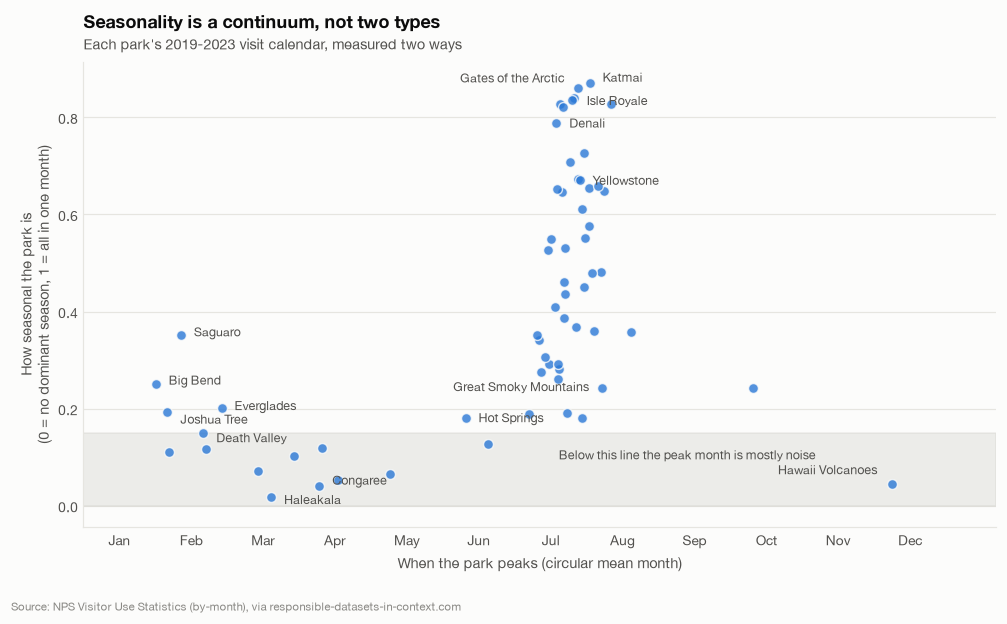

In [16]:
FLOOR = 0.15   # below this, a park is close to aseasonal and its peak month means little

offsets = {"Katmai NP & PRES": (0.18, 0.012), "Gates of the Arctic NP & PRES": (-0.18, 0.020),
           "Isle Royale NP": (0.18, -0.006), "Denali NP & PRES": (0.18, 0.0),
           "Yellowstone NP": (0.18, 0.0), "Great Smoky Mountains NP": (-0.18, 0.004),
           "Saguaro NP": (0.18, 0.006), "Big Bend NP": (0.18, 0.008),
           "Death Valley NP": (0.18, -0.010), "Joshua Tree NP": (0.18, -0.014),
           "Haleakala NP": (0.18, -0.004), "Congaree NP": (0.18, 0.012),
           "Everglades NP": (0.18, 0.004), "Hot Springs NP": (0.18, 0.0),
           "Hawaii Volcanoes NP": (-0.20, 0.030)}

fig, ax = npviz.new_figure(9.2, 5.4)
ax.axhspan(0, FLOOR, color=npviz.EMPHASIS_GRAY, alpha=0.30, zorder=1)
ax.text(8.9, FLOOR * 0.7, "Below this line the peak month is mostly noise",
        fontsize=8.2, color=npviz.TEXT_SECONDARY, ha="center", va="center")
ax.scatter(season_recent.peak_month, season_recent.concentration, s=42, color=npviz.BLUE,
           alpha=0.8, edgecolor=npviz.SURFACE, linewidth=0.9, zorder=3)
for park, (dx, dy) in offsets.items():
    if park in season_recent.index:
        x, y = season_recent.loc[park, "peak_month"], season_recent.loc[park, "concentration"]
        ax.text(x + dx, y + dy, park.replace(" NP & PRES", "").replace(" NP", ""),
                fontsize=8.2, color=npviz.TEXT_SECONDARY, va="center",
                ha="left" if dx > 0 else "right")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_xlim(0.5, 13.2)
ax.set_xlabel("When the park peaks (circular mean month)")
ax.set_ylabel("How seasonal the park is\n(0 = no dominant season, 1 = all in one month)")
npviz.title(ax, "Seasonality is a continuum, not two types",
            "Each park's 2019-2023 visit calendar, measured two ways")
npviz.source_note(fig)
npviz.save(fig, "16_seasonality_index_scatter")
plt.tight_layout()
plt.show()


This changes the reading of the earlier draft in two ways.

First, there are not two types. The 47 parks that peak in June, July or
August cover almost the entire range of seasonal strength, from Carlsbad
Caverns at 0.13 to Katmai at 0.87, with Great Smoky Mountains at 0.24. The
vertical spread inside that summer group is far wider than the gap between it
and anything else, so "summer peak" says almost nothing about how seasonal a
park is.

Second, the old labels were misleading at the bottom of the chart. Every
park that peaks outside June to September sits below 0.4, and most sit below
the shaded floor. Haleakala scored a February peak in the earlier draft and
was filed with the desert parks, but its concentration is 0.017, which means
its visits are essentially flat across the year and its "peak month" is
noise. Calling it winter-peaking was an artifact of taking an argmax over a
nearly uniform calendar. The honest statement is that it has no season worth
naming.

The heatmap below shows the same 63 calendars directly, now ordered by the
circular peak rather than by cutoffs we chose:

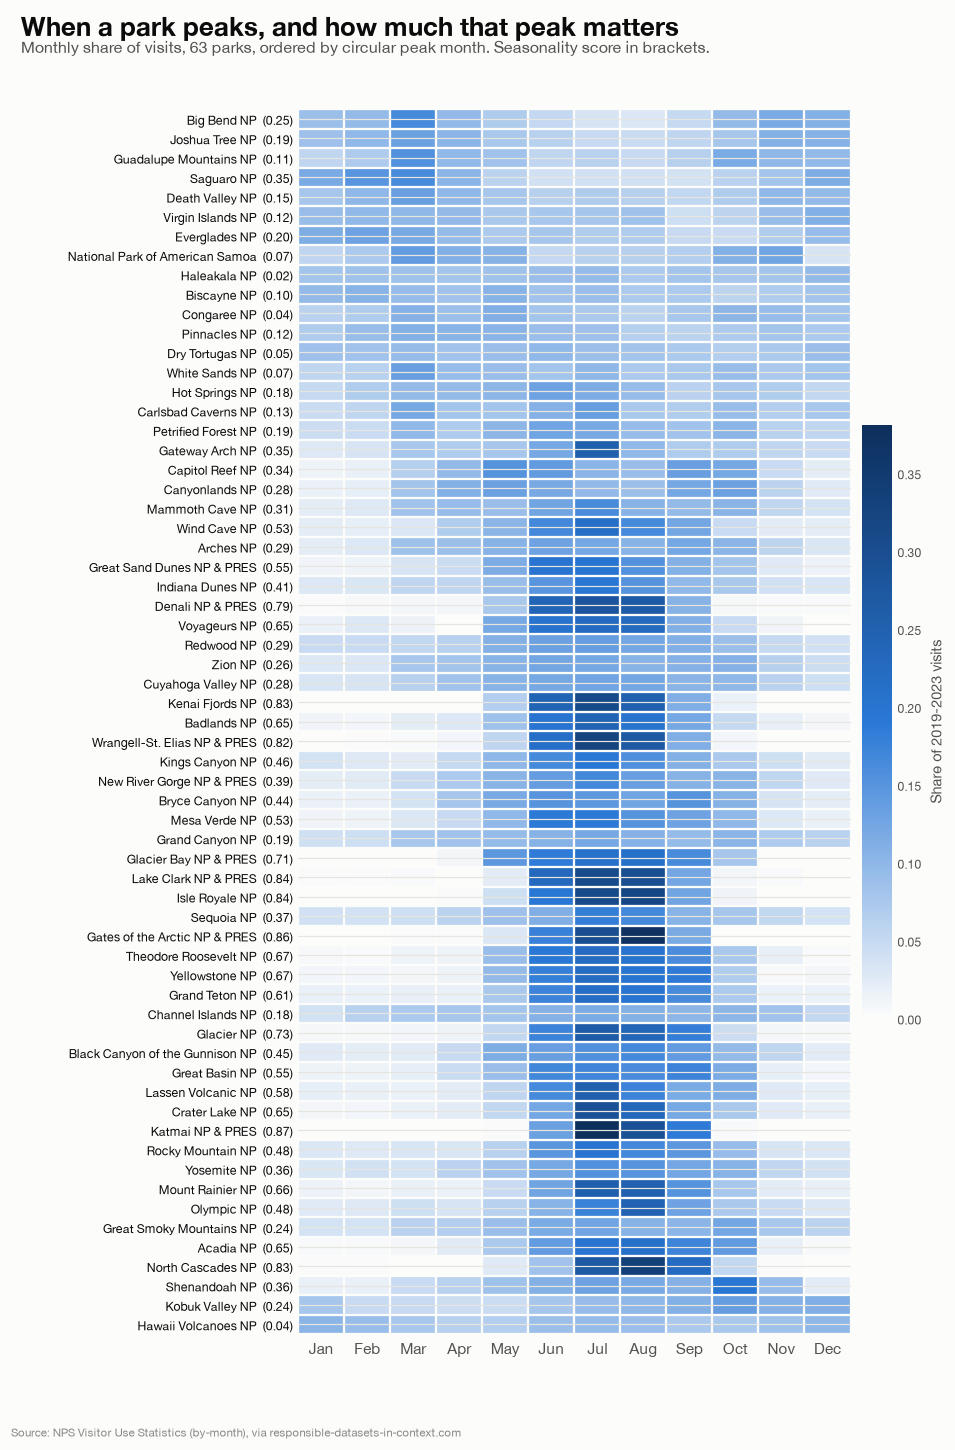

In [17]:
order = season_recent.peak_month.sort_values().index
mat = (npdata.monthly_matrix(recent, ["ParkName"])
       .pipe(lambda m: m.div(m.sum(axis=1), axis=0))
       .loc[order])
n = len(mat)

fig = plt.figure(figsize=(9.0, 12.8))
fig.patch.set_facecolor(npviz.SURFACE)
ax = fig.add_axes([0.30, 0.045, 0.60, 0.87])
ax.set_facecolor(npviz.SURFACE)

im = ax.imshow(mat.values, aspect="auto", cmap=npviz.SEQUENTIAL, vmin=0, vmax=mat.values.max())
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
                   fontsize=10, color=npviz.TEXT_SECONDARY)
ax.set_yticks(range(n))
ax.set_yticklabels([f"{p}  ({season_recent.loc[p, 'concentration']:.2f})" for p in mat.index],
                   fontsize=8.1, color=npviz.TEXT_PRIMARY)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=npviz.SURFACE, linewidth=1.5)
ax.tick_params(which="minor", length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("Share of 2019-2023 visits", fontsize=9.5, color=npviz.TEXT_SECONDARY)
cbar.ax.tick_params(labelsize=8, labelcolor=npviz.TEXT_SECONDARY)
cbar.outline.set_visible(False)

fig.suptitle("When a park peaks, and how much that peak matters", fontsize=17, fontweight="bold",
             color=npviz.TEXT_PRIMARY, x=0.02, ha="left", y=0.985)
fig.text(0.02, 0.955,
         "Monthly share of visits, 63 parks, ordered by circular peak month. "
         "Seasonality score in brackets.",
         fontsize=10.5, color=npviz.TEXT_SECONDARY, ha="left")
npviz.source_note(fig)
npviz.save(fig, "05_seasonal_typology_heatmap")
plt.show()


Reading down the rows, the score in brackets separates parks that share a
peak month but not a shape. Great Smoky Mountains and Katmai both peak in
late July, at 7.7 and 7.5 on the month scale, yet score 0.24 and 0.87. Same
timing, completely different calendars.

This also explains the small group of parks in Finding 1 that trend the
other way. They are mostly Katmai, Wrangell-St. Elias and Lake Clark, which
sit at the very top of the seasonality scale. Their seasons are short and
hard, tourism to them is growing, and the growth arrives inside the season
they already had.

Finally, the measure lets us ask a question the summer share cannot. When a
park becomes less seasonal, is it flattening its calendar, or moving its
peak to a different time of year?

In [18]:
from scipy import stats

# National: is the calendar flattening?
nat_season = npdata.seasonality_indices(npdata.monthly_matrix(df, ["Year"]))
conc_fit = npdata.trend(nat_season["concentration"])
eff_fit = npdata.trend(nat_season["eff_months"])
print(f"concentration {conc_fit.slope:+.4f}/decade (p = {conc_fit.p_value:.1e})")
print(f"effective months {eff_fit.slope:+.2f}/decade (p = {eff_fit.p_value:.1e}): "
      f"{nat_season.eff_months.loc[1979:1983].mean():.2f} in 1979-83 "
      f"-> {nat_season.eff_months.loc[2019:2023].mean():.2f} in 2019-23")

# Park level: flattening (concentration) vs shifting (peak timing)
season_park_year = npdata.seasonality_indices(npdata.monthly_matrix(df, ["ParkName", "Year"]))
conc_trend, peak_drift = {}, {}
for park, g in season_park_year.groupby(level=0):
    g = g.droplevel(0).dropna()
    if len(g) < 20:
        continue
    conc_trend[park] = npdata.trend(g["concentration"]).slope
    if g["concentration"].mean() >= FLOOR:      # only where a peak is meaningful
        unwrapped = pd.Series(np.unwrap(g["peak_month"].to_numpy(), period=12), index=g.index)
        peak_drift[park] = npdata.trend(unwrapped).slope
conc_trend, peak_drift = pd.Series(conc_trend), pd.Series(peak_drift)

t_stat, p_drift = stats.ttest_1samp(peak_drift, 0)
print(f"\nconcentration falling in {(conc_trend < 0).sum()} of {len(conc_trend)} parks")
print(f"peak drift, {len(peak_drift)} parks with a meaningful peak: "
      f"mean {peak_drift.mean():+.3f} months/decade (t = {t_stat:.2f}, p = {p_drift:.2f})")

r_check, p_check = stats.pearsonr(
    *pd.concat([conc_trend.rename("c"), npdata.park_trends(park_share).slope.rename("s")],
               axis=1).dropna().T.to_numpy())
print(f"agreement with the summer-share trend across parks: r = {r_check:.2f} (p = {p_check:.1e})")


concentration -0.0199/decade (p = 5.9e-12)
effective months +0.17/decade (p = 1.0e-10): 9.67 in 1979-83 -> 10.53 in 2019-23

concentration falling in 40 of 62 parks
peak drift, 57 parks with a meaningful peak: mean +0.040 months/decade (t = 0.78, p = 0.44)
agreement with the summer-share trend across parks: r = 0.85 (p = 2.0e-18)


Three results come out of this.

The national calendar is flattening. Visits now spread as if across 10.53
equally busy months, up from 9.67 in 1979 to 1983, and the concentration
index falls significantly. This is Finding 1 restated with a measure that
never mentions June, July or August, so the headline trend is not an
artifact of choosing summer as the window.

It agrees with the original measure. Park by park, the concentration trend
and the summer-share trend correlate at 0.85. The new index is a stronger
version of the same result rather than a different one.

Parks are flattening, not shifting. Across the 57 parks with a peak worth
measuring, the average drift in peak timing is 0.04 months per decade, which
is indistinguishable from zero (p = 0.44). Seasons are not moving earlier or
later in the year. They are getting less pronounced. This separates the two
ideas the feedback asked us to distinguish: the intensity of seasonality is
changing, its timing is not. It also sharpens the March result in the
[draft notebook](mini_project_draft.ipynb), because March gaining share
cannot be peaks creeping earlier. It has to come from which parks and which
trips people choose.

### The 2020 shock hit regions unevenly

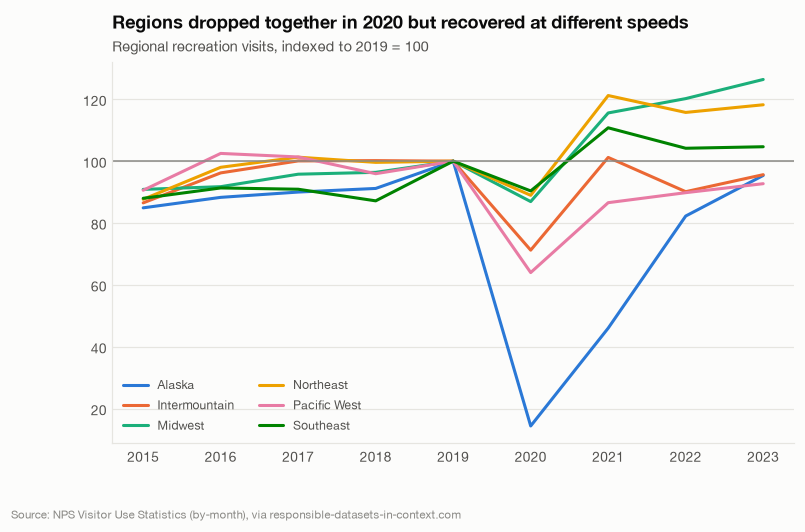

In [19]:
region_year = df.groupby(["Region", "Year"])["RecreationVisits"].sum().unstack("Year")
region_idx = region_year.div(region_year[2019], axis=0) * 100

fig, ax = npviz.new_figure(8, 4.5)
for color, region in zip(npviz.CATEGORICAL, region_idx.index):
    sub = region_idx.loc[region, 2015:2023]
    ax.plot(sub.index, sub.values, lw=2, color=color, label=region)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1, ls=(0, (1, 0)))
npviz.title(ax, "Regions dropped together in 2020 but recovered at different speeds",
            "Regional recreation visits, indexed to 2019 = 100")
ax.legend(loc="lower left", fontsize=8, ncol=2)
npviz.source_note(fig)
npviz.save(fig, "06_regional_covid_recovery")
plt.show()


**Data-quality note.** The data essay flags known counter outages (e.g.
Carlsbad Caverns' counter broken since 2019) and non-reporting zeros (e.g.
Kobuk Valley, 2014–2015), and that the 2024 annual figures were reportedly
suppressed after release. We restrict this analysis to 2023 and earlier for
that reason. Checking whether the 2020 regional drop is inflated by
non-reporting rather than real closures:

In [20]:
zeros_2020 = df[(df.Year == 2020) & (df.ZeroMonth)]
print(f"{len(zeros_2020)} zero-visit rows in 2020 across {zeros_2020.ParkName.nunique()} parks, "
      f"a small share of the {df[df.Year==2020].shape[0]} park-months that year, "
      "consistent with real (COVID) closures rather than a reporting artifact.")


46 zero-visit rows in 2020 across 26 parks, a small share of the 756 park-months that year, consistent with real (COVID) closures rather than a reporting artifact.


## Limitations and generalizability <a id='Limitations'></a>

- **Measurement, not census.** "Recreation visits" are estimated from
  traffic counters and manual counts, then adjusted by park-specific
  formulas that changed over 45 years, per the data essay. A slow drift
  toward more granular counting could itself produce part of a
  de-seasonalization signal, if peak-month counts were historically cruder
  than shoulder-month counts. We cannot rule this out from the visitation
  data alone, so we treat the finding as de-seasonalization of the measured
  share, not as a claim about literal foot traffic.
- **Definitional exclusions.** The data essay notes that recreation visits
  exclude commuters, researchers, staff and Indigenous residents of park
  lands, and that limited accessibility means visitors are not
  representative of the U.S. population. Our findings describe *counted*
  visitation behavior, not visitation in the broadest social sense.
- **Camping rate is a behavior proxy, not a survey.** `TentCampers` and
  `RVCampers` reflect campground *stays*, which are bounded by fixed
  campsite capacity in popular parks. A flat or declining rate could partly
  reflect a capacity ceiling rather than declining demand for camping. We
  cannot separate supply constraints from demand shifts with this dataset
  alone.
- **One shock event.** The 2020 regional-recovery pattern in Supporting
  context is a single case, one pandemic, not a repeated or generalizable
  pattern. We present it as texture, not as a claim in its own right.
- **Generalizability.** The 45-year trends in Findings 1 and 2 are our
  strongest basis for expecting the *direction* of these patterns to
  continue into future years. The *rate* of decline is unlikely to be
  constant, since both series slow markedly after about 2010. We would not
  extend either finding to park types absent from this file, which covers
  only the 63 units designated "National Park". National monuments,
  seashores and historic sites are excluded and may behave differently.
